# Battery Performance Prediction
Implementation of LSTM and XGBoost models for SOC and SOH prediction

In [1]:
# Import dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# XGBoost
import xgboost as xgb

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Load Processed Data

In [2]:
# Load data for models
with open('../models/lstm_data.pkl', 'rb') as f:
    lstm_data = pickle.load(f)
    
with open('../models/xgboost_data.pkl', 'rb') as f:
    xgboost_data = pickle.load(f)
    
X_xgboost = xgboost_data['X']
y_xgboost_soh = xgboost_data['y_soh']
features = xgboost_data['features']
metadata = xgboost_data['metadata']

print(f"LSTM data loaded for {len(lstm_data)} batteries")
print(f"XGBoost data shape: {X_xgboost.shape}")

LSTM data loaded for 4 batteries
XGBoost data shape: (636, 6)


## LSTM Model for SOH Prediction

In [3]:
def prepare_lstm_train_test(lstm_data, test_size=0.2):
    """Prepare train/test data for LSTM model"""
    X_all = []
    y_all = []
    
    # Combine data from all batteries
    for battery_id, data in lstm_data.items():
        X_all.append(data['X'])
        y_all.append(data['y'])
    
    X_all = np.vstack(X_all)
    y_all = np.hstack(y_all)
    
    # Split into train/test
    X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=test_size, random_state=42)
    
    # Standardize features
    # Reshape to 2D for scaling
    X_train_reshaped = X_train.reshape(-1, X_train.shape[-1])
    X_test_reshaped = X_test.reshape(-1, X_test.shape[-1])
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_reshaped)
    X_test_scaled = scaler.transform(X_test_reshaped)
    
    # Reshape back to 3D
    X_train = X_train_scaled.reshape(X_train.shape)
    X_test = X_test_scaled.reshape(X_test.shape)
    
    return X_train, X_test, y_train, y_test, scaler

# Prepare LSTM data
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm, scaler_lstm = prepare_lstm_train_test(lstm_data)

print(f"LSTM training data shape: {X_train_lstm.shape}")
print(f"LSTM test data shape: {X_test_lstm.shape}")

LSTM training data shape: (476, 10, 6)
LSTM test data shape: (120, 10, 6)


In [4]:
def create_lstm_model(input_shape):
    """Create LSTM model for sequence prediction"""
    model = Sequential([
        LSTM(64, activation='relu', return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(32, activation='relu'),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)  # Output layer for SOH prediction
    ])
    
    model.compile(
        optimizer='adam',
        loss='mse',
        metrics=['mae']
    )
    
    return model

# Create and train LSTM model
input_shape = (X_train_lstm.shape[1], X_train_lstm.shape[2])
lstm_model = create_lstm_model(input_shape)

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = lstm_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
12/12 [==============================] - 2s 34ms/step - loss: 0.3752 - mae: 0.5649 - val_loss: 0.1407 - val_mae: 0.2982
Epoch 2/100
12/12 [==============================] - 0s 8ms/step - loss: 0.1276 - mae: 0.2873 - val_loss: 0.0686 - val_mae: 0.2097
Epoch 3/100
12/12 [==============================] - 0s 7ms/step - loss: 0.0616 - mae: 0.2014 - val_loss: 0.0298 - val_mae: 0.1428
Epoch 4/100
12/12 [==============================] - 0s 7ms/step - loss: 0.0316 - mae: 0.1431 - val_loss: 0.0153 - val_mae: 0.0961
Epoch 5/100
12/12 [==============================] - 0s 7ms/step - loss: 0.0201 - mae: 0.1142 - val_loss: 0.0086 - val_mae: 0.0748
Epoch 6/100
12/12 [==============================] - 0s 7ms/step - loss: 0.0190 - mae: 0.1099 - val_loss: 0.0075 - val_mae: 0.0725
Epoch 7/100
12/12 [==============================] - 0s 7ms/step - loss: 0.0157 - mae: 0.0975 - val_loss: 0.0043 - val_mae: 0.0515
Epoch 8/100
12/12 [==============================] - 0s 7ms/step - loss: 0.0129 - 

4/4 [==============================] - 0s 2ms/step
LSTM Model Performance:
MSE: 0.000857
MAE: 0.021793
R²: 0.920011


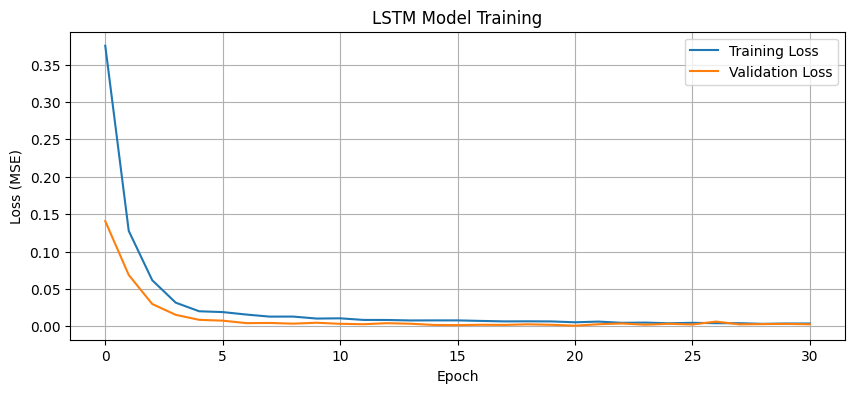

In [5]:
# Evaluate LSTM model
y_pred_lstm = lstm_model.predict(X_test_lstm).flatten()

lstm_mse = mean_squared_error(y_test_lstm, y_pred_lstm)
lstm_mae = mean_absolute_error(y_test_lstm, y_pred_lstm)
lstm_r2 = r2_score(y_test_lstm, y_pred_lstm)

print(f"LSTM Model Performance:")
print(f"MSE: {lstm_mse:.6f}")
print(f"MAE: {lstm_mae:.6f}")
print(f"R²: {lstm_r2:.6f}")

# Plot training history
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Training')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

## XGBoost Model for SOH Prediction

In [6]:
# Prepare data for XGBoost
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgboost, y_xgboost_soh, test_size=0.2, random_state=42
)

# Standardize features
scaler_xgb = StandardScaler()
X_train_xgb = scaler_xgb.fit_transform(X_train_xgb)
X_test_xgb = scaler_xgb.transform(X_test_xgb)

print(f"XGBoost training data shape: {X_train_xgb.shape}")
print(f"XGBoost test data shape: {X_test_xgb.shape}")

XGBoost training data shape: (508, 6)
XGBoost test data shape: (128, 6)


XGBoost Model Performance:
MSE: 0.000032
MAE: 0.003768
R²: 0.997138


<Figure size 1000x600 with 0 Axes>

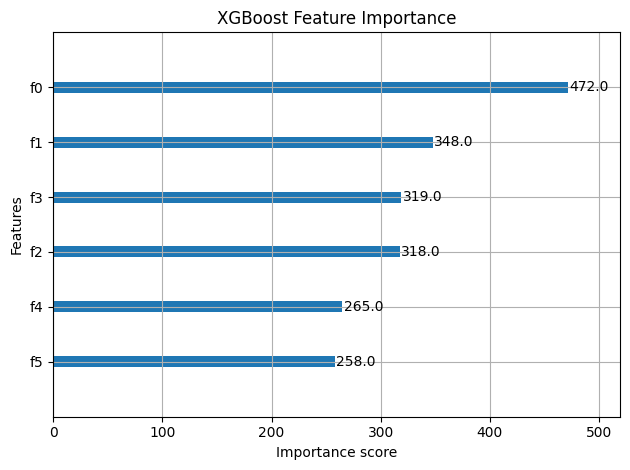

In [14]:
# Train XGBoost model
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Create evaluation sets (similar to original)
eval_set = [(X_train_xgb, y_train_xgb), (X_test_xgb, y_test_xgb)]

# Basic fit with evaluation
xgb_model.fit(
    X_train_xgb, 
    y_train_xgb,
    eval_set=eval_set,
    verbose=False
)

# If you want to implement early stopping manually, you can do:
best_iteration = xgb_model.best_iteration if hasattr(xgb_model, 'best_iteration') else None
if best_iteration:
    print(f"Best iteration: {best_iteration}")

# Evaluate XGBoost model
y_pred_xgb = xgb_model.predict(X_test_xgb)

xgb_mse = mean_squared_error(y_test_xgb, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test_xgb, y_pred_xgb)
xgb_r2 = r2_score(y_test_xgb, y_pred_xgb)

print(f"XGBoost Model Performance:")
print(f"MSE: {xgb_mse:.6f}")
print(f"MAE: {xgb_mae:.6f}")
print(f"R²: {xgb_r2:.6f}")

# Plot feature importance (as in original)
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=10)
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

XGBoost Model Performance:
MSE: 0.000032
MAE: 0.003768
R²: 0.997138


<Figure size 1000x600 with 0 Axes>

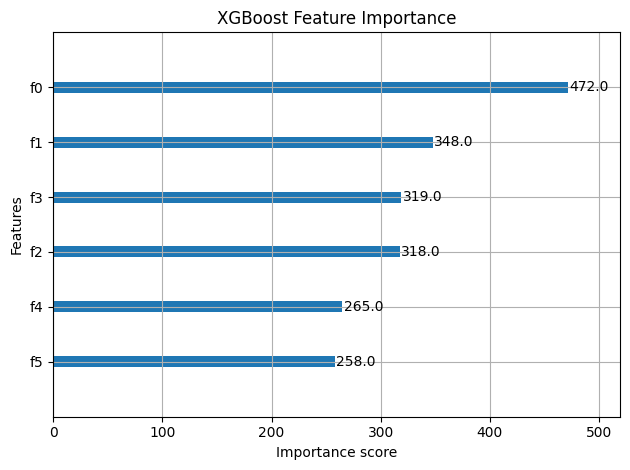

In [15]:
# Evaluate XGBoost model
y_pred_xgb = xgb_model.predict(X_test_xgb)

xgb_mse = mean_squared_error(y_test_xgb, y_pred_xgb)
xgb_mae = mean_absolute_error(y_test_xgb, y_pred_xgb)
xgb_r2 = r2_score(y_test_xgb, y_pred_xgb)

print(f"XGBoost Model Performance:")
print(f"MSE: {xgb_mse:.6f}")
print(f"MAE: {xgb_mae:.6f}")
print(f"R²: {xgb_r2:.6f}")

# Plot feature importance
plt.figure(figsize=(10, 6))
xgb.plot_importance(xgb_model, max_num_features=10)
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

## Model Comparison and Visualization

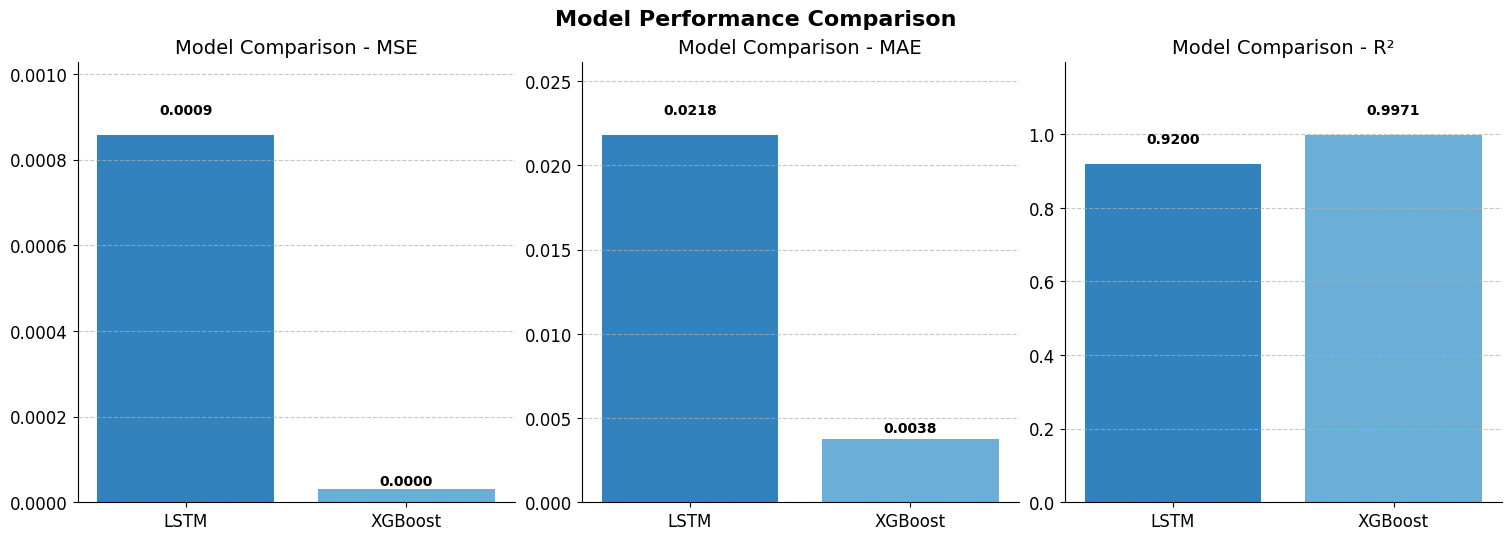

In [19]:
import matplotlib.pyplot as plt
import numpy as np

def plot_model_comparison(lstm_metrics, xgb_metrics):
    """
    Create robust model comparison plots
    
    Parameters:
    -----------
    lstm_metrics : dict
        Dictionary with 'mse', 'mae', and 'r2' keys for LSTM model
    xgb_metrics : dict
        Dictionary with 'mse', 'mae', and 'r2' keys for XGBoost model
    """
    # Models and metrics data
    models = ['LSTM', 'XGBoost']
    metrics = {
        'MSE': [lstm_metrics['mse'], xgb_metrics['mse']],
        'MAE': [lstm_metrics['mae'], xgb_metrics['mae']],
        'R²': [lstm_metrics['r2'], xgb_metrics['r2']]
    }
    
    # Create figure and axes
    fig, axs = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
    
    # Colors for bars
    colors = ['#3182bd', '#6baed6']
    
    # Plot each metric
    for i, (metric_name, values) in enumerate(metrics.items()):
        # Create bar plot
        bars = axs[i].bar(models, values, color=colors)
        axs[i].set_title(f'Model Comparison - {metric_name}', fontsize=14)
        axs[i].grid(axis='y', linestyle='--', alpha=0.7)
        
        # Add value labels on top of bars
        for j, v in enumerate(values):
            axs[i].text(j, v * 1.05, f"{v:.4f}", 
                        ha='center', va='bottom',
                        fontweight='bold')
        
        # Adjust y-axis limits to ensure labels are visible
        y_max = max(values) * 1.2
        axs[i].set_ylim(0, y_max)
        
        # Make plot more readable
        axs[i].spines['top'].set_visible(False)
        axs[i].spines['right'].set_visible(False)
        axs[i].tick_params(axis='both', which='major', labelsize=12)
    
    # Add overall title
    fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.05)
    
    plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

# Use your actual metrics:
lstm_metrics = {
    'mse': lstm_mse,
    'mae': lstm_mae, 
    'r2': lstm_r2
}

xgb_metrics = {
    'mse': xgb_mse,
    'mae': xgb_mae,
    'r2': xgb_r2
}

# Generate the comparison plot
plot_model_comparison(lstm_metrics, xgb_metrics)

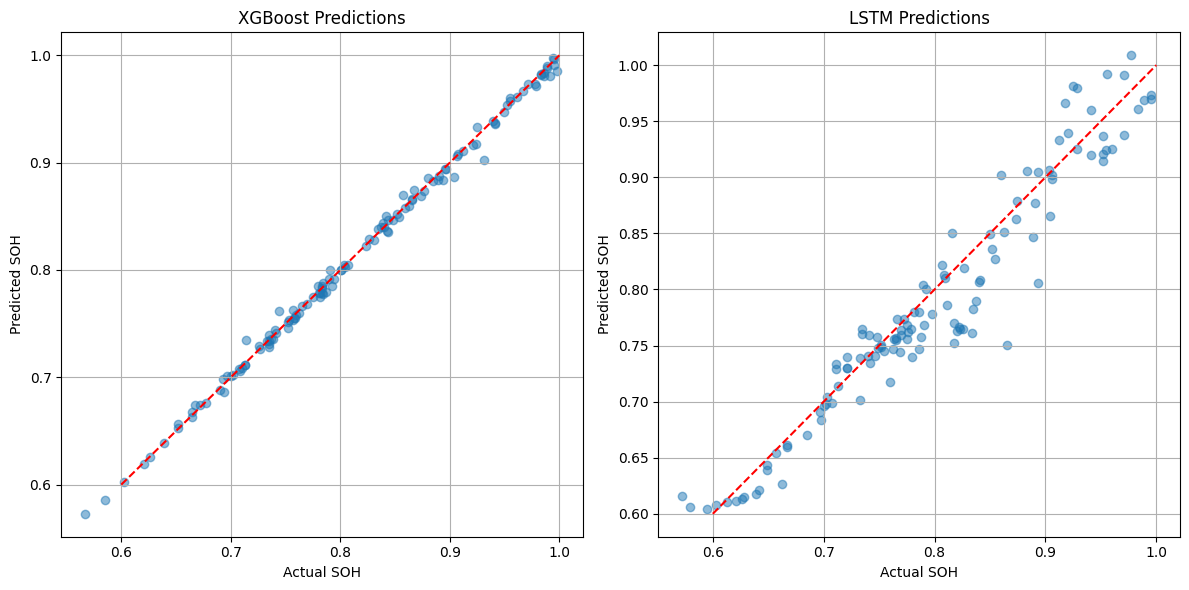

In [21]:
# Visualize predictions for both models
plt.figure(figsize=(12, 6))

# For XGBoost: Convert pandas Series to numpy array if needed
if hasattr(y_test_xgb, 'values'):
    y_test_xgb_np = y_test_xgb.values
    y_pred_xgb_np = y_pred_xgb
else:
    y_test_xgb_np = y_test_xgb
    y_pred_xgb_np = y_pred_xgb

# For LSTM: Convert pandas Series to numpy array if needed
if hasattr(y_test_lstm, 'values'):
    y_test_lstm_np = y_test_lstm.values
    y_pred_lstm_np = y_pred_lstm
else:
    y_test_lstm_np = y_test_lstm
    y_pred_lstm_np = y_pred_lstm

# Sort XGBoost data
sort_idx_xgb = np.argsort(y_test_xgb_np)
y_test_xgb_sorted = y_test_xgb_np[sort_idx_xgb]
y_pred_xgb_sorted = y_pred_xgb_np[sort_idx_xgb]

# Sort LSTM data
sort_idx_lstm = np.argsort(y_test_lstm_np)
y_test_lstm_sorted = y_test_lstm_np[sort_idx_lstm]
y_pred_lstm_sorted = y_pred_lstm_np[sort_idx_lstm]

# Plot XGBoost predictions
plt.subplot(1, 2, 1)
plt.scatter(y_test_xgb_sorted, y_pred_xgb_sorted, alpha=0.5)
plt.plot([0.6, 1.0], [0.6, 1.0], 'r--')
plt.xlabel('Actual SOH')
plt.ylabel('Predicted SOH')
plt.title('XGBoost Predictions')
plt.grid(True)

# Plot LSTM predictions
plt.subplot(1, 2, 2)
plt.scatter(y_test_lstm_sorted, y_pred_lstm_sorted, alpha=0.5)
plt.plot([0.6, 1.0], [0.6, 1.0], 'r--')
plt.xlabel('Actual SOH')
plt.ylabel('Predicted SOH')
plt.title('LSTM Predictions')
plt.grid(True)

plt.tight_layout()
plt.savefig('model_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## Save Models

In [22]:
# Save models
models_dir = '../models'
os.makedirs(models_dir, exist_ok=True)

# Save LSTM model
lstm_model.save(os.path.join(models_dir, 'lstm_soh_model'))

# Save XGBoost model
xgb_model.save_model(os.path.join(models_dir, 'xgboost_soh_model.json'))

# Save scalers
with open(os.path.join(models_dir, 'scaler_lstm.pkl'), 'wb') as f:
    pickle.dump(scaler_lstm, f)
    
with open(os.path.join(models_dir, 'scaler_xgb.pkl'), 'wb') as f:
    pickle.dump(scaler_xgb, f)
    
print("Models saved successfully.")

INFO:tensorflow:Assets written to: ../models\lstm_soh_model\assets
Models saved successfully.


## Conclusion

In this notebook, we implemented and compared two different approaches for battery SOH prediction:

1. LSTM: A deep learning approach that leverages the sequential nature of battery degradation
2. XGBoost: A powerful gradient boosting approach for tabular data

Based on the performance metrics, we can determine which model is more suitable for SOH prediction. The models can be further improved through hyperparameter optimization and additional feature engineering.